In [ ]:
import importlib.util, sys, json, platform
from pathlib import Path
import numpy as np
from typing import NamedTuple
from itertools import combinations
import time
from scipy import sparse
from scipy.sparse.linalg import eigsh
from scipy.linalg import expm

import jax
jax.config.update('jax_enable_x64', True)  # before constructing any JAX arrays
import jax.numpy as xp

L, U, HOPPING = 8, 4.0, 1.0
B = L
TRIAL_KIND = 'rhf'              # 'uhf' solves a staggered, collinear SCF problem
settings = dict(dt=0.01, weight_floor=1e-8, nwalkers=32, nsteps=20,
                nequil=15, nblocks=40, seed=1234)
if QUICK:
    settings.update(nwalkers=4, nsteps=3, nequil=2, nblocks=4)
assert B == L, 'This exact baseline supports maximal B only'
print(settings)


Backend: JAX 0.11.1 [CpuDevice(id=0)] x64: True
{'dt': 0.01, 'weight_floor': 1e-08, 'nwalkers': 32, 'nsteps': 20, 'nequil': 15, 'nblocks': 40, 'seed': 1234}


In [2]:
def put(a, index, value):
    """Functional indexed assignment with the same semantics in both backends."""
    if USE_JAX:
        return a.at[index].set(value)
    out = a.copy()
    out[index] = value
    return out


def tree_stack(items):
    if isinstance(items[0], tuple):
        return tuple(tree_stack([v[i] for v in items]) for i in range(len(items[0])))
    return xp.stack(items)


def batch(fn, walkers, *args):
    """All additional arguments carry the same leading walker dimension."""
    if USE_JAX:
        return jax.vmap(fn)(walkers, *args)
    return tree_stack([fn(tuple(w[k] for w in walkers), *(a[k] for a in args))
                       for k in range(walkers[0].shape[0])])


def sync(value):
    if USE_JAX:
        return jax.block_until_ready(value)
    return value


## 2. HF trial and an independent small-system energy reference

For collinear Hubbard HF,
$$
F_\alpha=h_1+U\operatorname{diag}(\rho_\beta),\qquad
F_\beta=h_1+U\operatorname{diag}(\rho_\alpha).
$$
The half-filled, even open chain has an RHF solution with both site densities equal to $1/2$. Its Fock matrix is $h_1+(U/2)I$: **the occupied orbitals are unchanged by $U$** although the HF energy is not. Thus the free-particle orbitals in the original example are a valid symmetry-restricted HF trial for this particular model. They need not minimize unrestricted HF.

`TRIAL_KIND = 'uhf'` solves the density equations from a staggered seed, checks convergence and the Fock/projector commutator, and uses that same new trial in both routes. This can break spin symmetry and depend on $U$. It finds a stationary solution, not a certified global HF minimum. The RHF shortcut deliberately refuses other fillings; the present `build_model` configures a half-filled chain.

The ED value is contextual. Agreement between two AFQMC implementations at fixed time step/population does **not** require either estimate to equal ED to machine precision.


In [3]:
def hf_energy(h1, interaction, ca, cb):
    pa, pb = ca @ ca.T, cb @ cb.T
    return float(np.trace(h1 @ (pa + pb)) + interaction * np.diag(pa) @ np.diag(pb))


def make_hf(h1, interaction, nelec, kind='rhf', mixing=0.5, tol=1e-11, maxiter=2000):
    """Real collinear HF, fixed spin populations. RHF option is the half-filled chain.

    UHF uses a staggered seed; convergence requires a density residual, followed by
    an independent Fock/projector commutator check. It is a stationary solution,
    not a guarantee of the globally lowest HF minimum.
    """
    n = len(h1)
    na, nb = nelec
    _, orbitals = np.linalg.eigh(h1)
    ca, cb = orbitals[:, :na], orbitals[:, :nb]
    if kind == 'rhf':
        if na != nb or na + nb != n:
            raise ValueError('This RHF shortcut is restricted to the half-filled chain')
        ra, rb = np.sum(ca**2, axis=1), np.sum(cb**2, axis=1)
        np.testing.assert_allclose(ra, 0.5, atol=1e-12)
        np.testing.assert_allclose(rb, 0.5, atol=1e-12)
        iterations = 0
    elif kind == 'uhf':
        ra = np.clip(na/n + 0.1 * (-1.)**np.arange(n), 0, 1)
        rb = np.clip(nb/n - 0.1 * (-1.)**np.arange(n), 0, 1)
        for iterations in range(1, maxiter + 1):
            ca = np.linalg.eigh(h1 + interaction * np.diag(rb))[1][:, :na]
            cb = np.linalg.eigh(h1 + interaction * np.diag(ra))[1][:, :nb]
            newa, newb = np.sum(ca**2, axis=1), np.sum(cb**2, axis=1)
            residual = max(np.max(abs(newa-ra)), np.max(abs(newb-rb)))
            if residual < tol:
                ra, rb = newa, newb
                break
            ra = (1-mixing)*ra + mixing*newa
            rb = (1-mixing)*rb + mixing*newb
        else:
            raise RuntimeError('UHF density did not converge')
    else:
        raise ValueError('kind must be rhf or uhf')
    pa, pb = ca@ca.T, cb@cb.T
    fa, fb = h1 + interaction*np.diag(rb), h1 + interaction*np.diag(ra)
    commutator = max(np.linalg.norm(fa@pa-pa@fa), np.linalg.norm(fb@pb-pb@fb))
    assert commutator < 1e-8
    return ca, cb, dict(energy=hf_energy(h1, interaction, ca, cb),
                       iterations=iterations, commutator=commutator,
                       magnetization=ra-rb)


def ed_reference(h1, interaction, nelec):
    """Sparse fixed-sector ED for the real nearest-neighbour open chain."""
    n = len(h1)
    def kinetic(number):
        strings = [frozenset(c) for c in combinations(range(n), number)]
        index = {s:k for k,s in enumerate(strings)}
        rows, cols, values = [], [], []
        for col,s in enumerate(strings):
            for i in range(n-1):
                for source,target in ((i,i+1),(i+1,i)):
                    if source in s and target not in s:
                        rows.append(index[frozenset((s-{source})|{target})])
                        cols.append(col); values.append(h1[target,source])
        return sparse.csr_matrix((values,(rows,cols)),shape=(len(strings),)*2),strings
    ka,sa = kinetic(nelec[0]); kb,sb = kinetic(nelec[1])
    h = sparse.kron(ka,sparse.eye(len(sb))) + sparse.kron(sparse.eye(len(sa)),kb)
    h = h + sparse.diags([interaction*len(a&b) for a in sa for b in sb])
    if h.shape[0] < 3:
        return float(np.linalg.eigvalsh(h.toarray())[0])
    return float(eigsh(h,k=1,which='SA',tol=1e-12,v0=np.ones(h.shape[0]),return_eigenvectors=False)[0])


## 3. Exact Slater-to-MPS conversion: what is frozen, what evolves

[Fishman and White (2015)](https://arxiv.org/abs/1504.07701) construct Gaussian-state MPS through rotations of correlation-matrix blocks and inverse many-body gates. The following is a maximal-block specialization of that construction.

For orthonormal occupied orbitals $Q$, $P=QQ^T$ is a projector. After each *exact* disentangling, the full remaining block is still a projector. To select a mode of prescribed occupation, use
$$
v=P v_{\rm ref}\quad(\mathrm{occ}=1),\qquad
v=(I-P)v_{\rm ref}\quad(\mathrm{occ}=0),
$$
and normalize it. A single application suffices at maximal $B$; repeated spectral squaring is unnecessary. If the old reference has negligible projection, choose a nonzero projector column. Empty-row leakage is measured to detect failure of the exact replay assumptions.

The host plan fixes a product occupation string with the correct total particle number, reference vectors and gate positions. **It does not freeze the walker or its physical site occupations.** Every new walker recomputes all numerical vectors and rotation angles. The stored references select a coordinate chart within occupied/empty subspaces.

On a spinless MPS bond, the quantum number is the cumulative particle count to its left. Splitting two sites obeys
$$
q_{\rm middle}=q_{\rm left}+n_i=q_{\rm right}-n_{i+1}.
$$
`sector_split` groups rows and columns by this same middle count and takes an SVD of each matching block. The product string and gate schedule fix the **allocated sector sizes**; singular vectors and singular values change every time. Retaining zero singular values keeps array shapes static for JAX. No particle is pinned to a particular physical site.

QR normalization and the occupied-minor determinant are retained as a separate physical scalar. Dropping either scalar can preserve normalized energies while corrupting HS overlap ratios. The two spin channels are interleaved with their fermionic sign, not simply multiplied as distinguishable chains.

This is a forward simulation. The fallback chart selection, degenerate SVDs and discrete CP decisions are not advertised as differentiable.


In [4]:
def max_block_plan(c):
    """Host planning only: full remaining blocks, occupations and reference vectors."""
    if np.iscomplexobj(c):
        raise ValueError('Real orbitals are required')
    np.testing.assert_allclose(c.T@c,np.eye(c.shape[1]),atol=1e-10,rtol=0)
    u = np.array(c, dtype=float, copy=True)
    n = len(c); occ = np.zeros(n,dtype=int); refs=[]
    for k in range(n-1):
        values,vectors=np.linalg.eigh((u@u.T)[k:,k:])
        empty = values[0] <= 1-values[-1]
        v = vectors[:,0 if empty else -1].copy()
        occ[k] = 0 if empty else 1
        refs.append(v.copy())
        for j in range(len(v)-1,0,-1):
            theta=np.arctan2(v[j],v[j-1]); co,si=np.cos(theta),np.sin(theta)
            v[j-1],v[j]=co*v[j-1]+si*v[j],0
            p=k+j-1; left,right=u[p].copy(),u[p+1].copy()
            u[p],u[p+1]=co*left+si*right,-si*left+co*right
    occ[-1]=int(round(u[-1]@u[-1]))
    assert occ.sum()==c.shape[1]
    return occ,tuple(refs)


def qr_with_scale(c):
    """Real reduced QR, positive diagonal convention, exact Slater scale det(R)."""
    q,r=xp.linalg.qr(c,mode='reduced')
    signs=xp.where(xp.diag(r)<0,-1.,1.)
    q=q*signs[None,:]
    return q,xp.prod(xp.diag(r)*signs)


def channel_angles(q, plan):
    """Maximal-B replay: one projector application, no repeated spectral squaring.

    A largest-column fallback avoids an orthogonal reference. This is forward-only;
    no differentiability claim is made for the chart choice or sector SVDs.
    """
    occ,refs=plan
    u=q; gates=[]
    for k,ref in enumerate(refs):
        block=u[k:]@u[k:].T
        projector=block if occ[k] else xp.eye(len(q)-k,dtype=q.dtype)-block
        v=projector@xp.asarray(ref)
        norms=xp.linalg.norm(projector,axis=0)
        fallback=projector[:,xp.argmax(norms)]
        v=xp.where(xp.linalg.norm(v)>1e-12*xp.max(norms),v,fallback)
        norm=xp.linalg.norm(v)
        v=v/xp.where(norm>0,norm,1.)
        v=xp.where(norm>0,v,xp.full_like(v,xp.nan))
        for j in range(len(ref)-1,0,-1):
            x,y=v[j-1],v[j]
            theta=xp.arctan2(y,xp.where((x==0)&(y==0),1.,x))
            co,si=xp.cos(theta),xp.sin(theta)
            v=put(v,j-1,co*x+si*y); v=put(v,j,0.)
            p=k+j-1; left,right=u[p],u[p+1]
            u=put(u,p,co*left+si*right)
            u=put(u,p+1,-si*left+co*right)
            gates.append((p,theta))
    return gates,u


In [5]:
def sector_split(t, ql, qr):
    """Exact factorization with fixed allocated ranks, including zero singular values."""
    dl,_,_,dr=t.shape; matrix=t.reshape(dl*2,2*dr)
    row_charge=(ql[:,None]+np.arange(2)).ravel()
    col_charge=(qr[None,:]-np.arange(2)[:,None]).ravel()
    left_parts,right_parts,charges=[],[],[]
    for charge in sorted(set(row_charge)&set(col_charge)):
        rows=np.flatnonzero(row_charge==charge); cols=np.flatnonzero(col_charge==charge)
        uu,ss,vh=xp.linalg.svd(matrix[np.ix_(rows,cols)],full_matrices=False)
        rank=min(len(rows),len(cols))
        left_parts.append(put(xp.zeros((dl*2,rank),dtype=t.dtype),rows,uu))
        right_parts.append(put(xp.zeros((rank,2*dr),dtype=t.dtype),(slice(None),cols),ss[:,None]*vh))
        charges.extend([charge]*rank)
    return (xp.concatenate(left_parts,axis=1).reshape(dl,2,-1),
            xp.concatenate(right_parts,axis=0).reshape(-1,2,dr),np.asarray(charges,dtype=int))


def spin_channel(q, plan):
    occ,_=plan
    ts=[xp.asarray(np.eye(2)[o]).reshape(1,2,1) for o in occ]
    charges=[np.zeros(1,dtype=int)]
    for o in occ:charges.append(charges[-1]+o)
    gates,u=channel_angles(q,plan)
    for site,theta in reversed(gates):
        co,si=xp.cos(theta),xp.sin(theta)
        gate=xp.stack([xp.array([1.,0.,0.,0.]),xp.stack([0.*co,co,si,0.*co]),
                       xp.stack([0.*co,-si,co,0.*co]),xp.array([0.,0.,0.,1.])]).reshape(2,2,2,2)
        pair=xp.tensordot(ts[site],ts[site+1],axes=1)
        pair=xp.einsum('xypq,apqb->axyb',gate,pair)
        ts[site],ts[site+1],charges[site+1]=sector_split(pair,charges[site],charges[site+2])
    scale=xp.linalg.det(u[np.flatnonzero(occ),:])
    leakage=xp.linalg.norm(u[np.flatnonzero(occ==0),:])
    return tuple(ts),charges,scale,leakage


def interleave(a,qa,b,qb):
    """Spatial basis |0>,|alpha>,|beta>,|alpha beta>; fermionic interleaving included."""
    tensors=[]
    for i,(aa,bb) in enumerate(zip(a,b)):
        sectors=[]
        for nb in (0,1):
            for na in (0,1):
                sign=xp.asarray((-1.)**(na*qb[i]))
                sectors.append(xp.einsum('ar,b,bs->abrs',aa[:,na,:],sign,bb[:,nb,:]))
        tensor=xp.stack(sectors,axis=2)
        tensors.append(tensor.reshape(aa.shape[0]*bb.shape[0],4,aa.shape[2]*bb.shape[2]))
    return tuple(tensors)


def walker_mps(walker, plans):
    """One conversion returns normalized circuit tensors, physical scalar and leakage."""
    qa,ra=qr_with_scale(walker[0]); qb,rb=qr_with_scale(walker[1])
    a,qna,sa,la=spin_channel(qa,plans[0]); b,qnb,sb,lb=spin_channel(qb,plans[1])
    return interleave(a,qna,b,qnb),ra*rb*sa*sb,xp.sqrt(la*la+lb*lb)


## 4. Local HS operator and overlap environments

The supplied real spin decomposition uses
$$
\gamma=\operatorname{arcosh}(e^{\Delta\tau U/2}),\qquad
s_\alpha(x)=e^{-\Delta\tau U/2+x\gamma},\quad
s_\beta(x)=e^{-\Delta\tau U/2-x\gamma},\quad x=\pm1.
$$
Its factors include the common one-particle prefactor; omitting it changes the propagator. Both fields have prior probability $1/2$.

Scaling row $i$ of the two Slater matrices by these factors is exactly the Fock-space operation
$$
D_i(x)=\operatorname{diag}(1,s_\alpha,s_\beta,s_\alpha s_\beta),\qquad
A_i^{\,p}\leftarrow D_i(x)_{pp} A_i^{\,p}.
$$
A diagonal on-site operation changes no bond dimensions and requires **no SVD**. Keep the physical scalar from conversion unchanged during this sweep; do not renormalize a tensor without compensating its scalar.

Let $T_i$ be the trial tensor, $A_i$ the current walker tensor, $\mathcal L_i$ the overlap contraction left of $i$, and $\mathcal R_{i+1}$ the contraction right of $i$. Compute four numbers
$$
g_i(p)=\sum_{a,b,c,d}\mathcal L_i(a,b)\,T_i(a,p,c)^*\,A_i(b,p,d)\,\mathcal R_{i+1}(c,d).
$$
Both proposals then cost two four-component dot products:
$$
O_i(x)=s_{\rm walker}\sum_p D_i(x)_{pp}\,g_i(p).
$$
Precompute all right environments once. Sweep left to right; after choosing a field, update the current tensor and absorb it into the left environment. The right environment remains valid because it contains only sites not yet changed. Already-consumed tensors need not be retained: their chosen updates are in the left environment.

This cache works with an arbitrary fixed MPS trial, including a DMRG trial. Only the walker conversion assumes Gaussian/Slater walkers.


In [6]:
def left_contract(left, trial, walker):
    # Factor contraction to avoid a large four-bond intermediate.
    temp=xp.tensordot(left,walker,axes=([1],[0]))
    return xp.tensordot(xp.conj(trial),temp,axes=([0,1],[0,1]))


def right_contract(right, trial, walker):
    temp=xp.tensordot(walker,right,axes=([2],[1]))  # walker-left, p, trial-right
    return xp.tensordot(xp.conj(trial),temp,axes=([1,2],[1,2]))


def overlap_tensors(trial,walker):
    left=xp.ones((1,1),dtype=xp.result_type(trial[0],walker[0]))
    for b,a in zip(trial,walker):left=left_contract(left,b,a)
    return left.reshape(())


def physical_contributions(left, right, trial, walker):
    """Four g[p] such that a local diagonal proposal has overlap sum_p d[p] g[p]."""
    temp=xp.tensordot(left,walker,axes=([1],[0]))  # trial-left, p, walker-right
    temp=xp.tensordot(temp,right,axes=([2],[1]))   # trial-left, p, trial-right
    return xp.sum(xp.conj(trial)*temp,axis=(0,2))


## 5. MPS local energy without an HF shortcut

For Hermitian $H$, cache the fixed MPS $H|\Psi_T\rangle$ once and measure
$$
E_L=\frac{\langle H\Psi_T|\phi\rangle}{\langle\Psi_T|\phi\rangle}.
$$
The walker scalar cancels in this ratio. The numerator and denominator are actual MPS contractions; the MPS route never delegates its local energy to the determinant Green function.

The open-chain Hubbard MPO below includes fermionic signs in the stated local ordering. A host QR/SVD sweep compresses the fixed $H|\Psi_T\rangle$ at relative threshold $10^{-14}$, with a reported discarded-norm bound. Walker MPS are never truncated. For a strict zero-threshold experiment, call `compress_fixed_trial(..., relative_tol=0.0)` instead. Trial norm and HF expectation value are independently checked at construction.


In [7]:
def mpo_hubbard(n, hopping, interaction):
    eye=np.eye(4); ca=np.zeros((4,4));cb=np.zeros((4,4))
    ca[1,0]=ca[3,2]=1.;cb[2,0]=1.;cb[3,1]=-1.
    pa=np.diag([1.,-1.,1.,-1.]);pb=np.diag([1.,1.,-1.,-1.])
    docc=np.diag([0.,0.,0.,1.]);w=np.zeros((n,6,4,4,6))
    for i in range(n):
        w[i,0,:,:,0]=eye;w[i,5,:,:,5]=eye;w[i,0,:,:,5]=interaction*docc
        for k,op in enumerate((ca@pb,ca.T@pb,pa@cb,pa@cb.T),1):w[i,0,:,:,k]=op
        for k,op in enumerate((ca.T,ca,cb.T,cb),1):w[i,k,:,:,5]=-hopping*op
    return w


def apply_mpo(w,ts):
    out=[]
    for i,(op,a) in enumerate(zip(w,ts)):
        if i==0:op=op[0:1]
        if i==len(ts)-1:op=op[:,:,:,5:6]
        t=np.einsum('apqb,cqd->acpbd',op,np.asarray(a))
        out.append(t.reshape(t.shape[0]*t.shape[1],4,t.shape[3]*t.shape[4]))
    return out


def compress_fixed_trial(ts,relative_tol=1e-14):
    """Host-only QR/SVD sweep on fixed H|trial>; report discarded Frobenius bound."""
    ts=[np.array(t,copy=True) for t in ts];discarded=0.
    for i in range(len(ts)-1):
        dl,d,dr=ts[i].shape;q,r=np.linalg.qr(ts[i].reshape(dl*d,dr))
        ts[i]=q.reshape(dl,d,-1);ts[i+1]=np.tensordot(r,ts[i+1],axes=1)
    for i in range(len(ts)-1,0,-1):
        dl,d,dr=ts[i].shape;u,s,vh=np.linalg.svd(ts[i].reshape(dl,d*dr),full_matrices=False)
        rank=max(1,int(np.sum(s>relative_tol*max(s[0],1e-300))))
        discarded+=float(s[rank:]@s[rank:])
        ts[i]=vh[:rank].reshape(rank,d,dr)
        ts[i-1]=np.tensordot(ts[i-1],u[:,:rank]*s[:rank],axes=1)
    return tuple(xp.asarray(t) for t in ts),np.sqrt(discarded)


class Model(NamedTuple):
    h1: object
    interaction: float
    nelec: tuple
    trial_a: object
    trial_b: object
    plans: tuple
    trial: tuple
    htrial: tuple


def build_model(n=8,interaction=4.,hopping=1.,trial_kind='rhf'):
    h1=-hopping*(np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))
    nelec=(n//2,n//2)
    ca,cb,hf=make_hf(h1,interaction,nelec,kind=trial_kind)
    plans=(max_block_plan(ca),max_block_plan(cb))
    ts,scale,leak=walker_mps((xp.asarray(ca),xp.asarray(cb)),plans)
    # Absorb the trial's physical gauge once. Walker scales remain separate.
    ts=(ts[0]*scale,)+ts[1:]
    hts,discard=compress_fixed_trial(apply_mpo(mpo_hubbard(n,hopping,interaction),ts))
    np.testing.assert_allclose(overlap_tensors(ts,ts),1.,atol=1e-11,rtol=0)
    np.testing.assert_allclose(overlap_tensors(ts,hts),hf['energy'],atol=1e-10,rtol=0)
    info=dict(hf=hf,ed=ed_reference(h1,interaction,nelec),
              htrial_discard_bound=discard,initial_leakage=float(leak),
              walker_bonds=[a.shape[0] for a in ts]+[1])
    return Model(xp.asarray(h1),interaction,nelec,xp.asarray(ca),xp.asarray(cb),plans,ts,hts),info


def make_estimators(model):
    """Both routes use the same physical HF trial; MPS energy never uses SD Greens."""
    def sd_overlap(walker):
        a,b=walker
        return xp.linalg.det(model.trial_a.T@a)*xp.linalg.det(model.trial_b.T@b)
    def sd_energy(walker):
        a,b=walker
        ga=xp.linalg.solve((model.trial_a.T@a).T,a.T).T@model.trial_a.T
        gb=xp.linalg.solve((model.trial_b.T@b).T,b.T).T@model.trial_b.T
        return xp.sum(model.h1*(ga+gb).T)+model.interaction*xp.sum(xp.diag(ga)*xp.diag(gb))
    def mps_overlap(walker):
        ts,scale,_=walker_mps(walker,model.plans)
        return scale*overlap_tensors(model.trial,ts)
    def mps_energy(walker):
        ts,_,_=walker_mps(walker,model.plans)
        return overlap_tensors(model.htrial,ts)/overlap_tensors(model.trial,ts)
    return sd_overlap,sd_energy,mps_overlap,mps_energy


## 6. Matched CPMC kernels

`make_kernels` returns a pure determinant reference and the cached MPS route. Both independently update their own Slater matrices; the MPS route also builds and updates its temporary MPS during HS propagation. Matrices remain the stabilized persistent representation across kinetic half-steps.

| Work per walker per propagation step | Rebuild every proposal | Local HS cache |
|---|---:|---:|
| Conversions after kinetic half-steps | 2 | 2 |
| Extra conversions for HS proposals | $2L$ | 0 |
| SVDs inside HS site loop | repeated conversion SVDs | 0 |
| Both field overlaps at a site | two complete rebuilds/contractions | shared $g_i(p)$, two dot products |

Measurement and block-boundary overlap refreshes add conversions outside this table. Kinetic propagation is still performed on the Slater matrices, followed by reconstruction; replacing it with an MPS gate decomposition is a separate project. Maximal-$B$ MPS bonds can grow exponentially, so this is an exact validation baseline rather than a scalable large-system claim.

To isolate the representation change, preserve the **attached `cpmc_slow` policy** exactly: threshold `0.5 * O_new/O_old` by `weight_floor`, normalization `r0 + r1 + 1e-13`, no cap after each HS site, and the existing kinetic/feedback caps. The reference is the original overlap-based SD/HF route, not `trot`'s separate fast Green-update implementation. Raw zero overlaps are not silently regularized; the validation fails on nonfinite states.

The portable implementation accepts pre-generated random numbers. This makes every proposed field and resampling decision directly comparable. Its NumPy PCG64 stream need not reproduce an old JAX seed's trajectory. The native section below uses the actual library's JAX random stream.


In [8]:
class StepParameters(NamedTuple):
    dt: float=0.01
    weight_floor: float=1e-8
    weight_cap: float=100.
    damping: float=0.1


class CoreState(NamedTuple):
    walkers: tuple
    weights: object
    overlaps: object
    shift: object
    energy_estimate: object
    nodes: object


def propagation_context(model,dt):
    half=xp.asarray(expm(-0.5*dt*np.asarray(model.h1)))
    gamma=np.arccosh(np.exp(0.5*dt*model.interaction))
    hs=xp.asarray(np.exp(-0.5*dt*model.interaction)*np.array(
        [[np.exp(gamma),np.exp(-gamma)],[np.exp(-gamma),np.exp(gamma)]]))
    return half,hs


def make_kernels(model,pars,reference_via_mps=False):
    """Two matched kernels. Recompute-SD is the oracle for local cached MPS.

    Exactly reproduce attached cpmc_slow policy: threshold 0.5*O'/O for fields,
    norm=r0+r1+1e-13, no per-site cap, caps after kinetic updates and feedback.
    A raw overlap zero is not silently regularized. Validation fails on nonfinite state.
    """
    sd_overlap,sd_energy,mps_overlap,mps_energy=make_estimators(model)
    if reference_via_mps:
        sd_overlap=mps_overlap  # Deliberately naive reconstruction, for timing only.
    n=len(model.h1)
    def sweep(walker,old_overlap,weight,randoms,hs,use_mps):
        if use_mps:
            tensors,scale,leakage=walker_mps(walker,model.plans)
            right=[None]*(n+1);right[n]=xp.ones((1,1))
            for i in range(n-1,-1,-1):right[i]=right_contract(right[i+1],model.trial[i],tensors[i])
            left=xp.ones((1,1))
            overlap=scale*right[0].reshape(())
        else:
            overlap=sd_overlap(walker);leakage=xp.asarray(0.)
        ratio=overlap/old_overlap
        ratio=xp.where(ratio<pars.weight_floor,0.,ratio)
        nodes=xp.asarray(ratio<=0,dtype=xp.int64)
        weight=weight*ratio
        weight=xp.where(weight>pars.weight_cap,0.,weight)
        proposals=[];probabilities=[];choices=[];weight_history=[];ratios=[]
        for i in range(n):
            d=xp.stack([xp.ones(2),hs[:,0],hs[:,1],hs[:,0]*hs[:,1]],axis=1)
            if use_mps:
                g=physical_contributions(left,right[i+1],model.trial[i],tensors[i])
                proposed=scale*(d@g)
            else:
                p0=(put(walker[0],i,walker[0][i]*hs[0,0]),put(walker[1],i,walker[1][i]*hs[0,1]))
                p1=(put(walker[0],i,walker[0][i]*hs[1,0]),put(walker[1],i,walker[1][i]*hs[1,1]))
                proposed=xp.stack([sd_overlap(p0),sd_overlap(p1)])
            raw_ratios=0.5*proposed/overlap
            r=xp.where(raw_ratios<pars.weight_floor,0.,raw_ratios)
            nodes=nodes+xp.sum(r<=0)
            norm=r[0]+r[1]+1e-13
            probability=r[0]/norm
            chosen=xp.where(randoms[i]<probability,0,1)
            walker=(put(walker[0],i,walker[0][i]*hs[chosen,0]),
                    put(walker[1],i,walker[1][i]*hs[chosen,1]))
            if use_mps:
                updated=tensors[i]*d[chosen][None,:,None]
                left=left_contract(left,model.trial[i],updated)
                # No SVD, no normalization, no reconstruction. Earlier tensors need
                # not be stored: their chosen updates are already in the left environment.
            overlap=proposed[chosen]
            weight=weight*norm
            proposals.append(proposed);probabilities.append(probability);choices.append(chosen)
            ratios.append(raw_ratios);weight_history.append(weight)
        trace=(xp.stack(proposals),xp.stack(probabilities),xp.stack(choices),
               xp.stack(weight_history),xp.stack(ratios),leakage)
        return walker,weight,overlap,nodes,trace
    def sd_sweep(w,o,wgt,r,hs):return sweep(w,o,wgt,r,hs,False)
    def mps_sweep(w,o,wgt,r,hs):return sweep(w,o,wgt,r,hs,True)
    def make_step(use_mps):
        overlap_fn=mps_overlap if use_mps else sd_overlap
        sweep_fn=mps_sweep if use_mps else sd_sweep
        def step(state,uniforms,half,hs):
            half_walkers=tuple(half@w for w in state.walkers)
            fn=lambda w,o,wgt,r:sweep_fn(w,o,wgt,r,hs)
            walkers,weights,overlaps,node_counts,traces=batch(fn,half_walkers,state.overlaps,state.weights,uniforms)
            walkers=tuple(half@w for w in walkers)
            overlaps_new=batch(overlap_fn,walkers)
            ratio=overlaps_new/overlaps
            ratio=xp.where(ratio<pars.weight_floor,0.,ratio)
            nodes=state.nodes+xp.sum(node_counts)+xp.sum(ratio<=0)
            weights=weights*ratio
            weights=xp.where(weights>pars.weight_cap,0.,weights)
            weights=weights*xp.exp(pars.dt*state.shift)
            weights=xp.where(weights>pars.weight_cap,0.,weights)
            average=xp.maximum(xp.mean(weights),1e-300)
            shift=state.energy_estimate-pars.damping*xp.log(average)/pars.dt
            return CoreState(walkers,weights,overlaps_new,shift,state.energy_estimate,nodes),traces
        return step
    return sd_sweep,mps_sweep,make_step(False),make_step(True)


## 7. Stabilization, measurements, population control and assertions

At every block: QR-stabilize each route, refresh overlaps, compute raw local energies, apply the source clipping policy, update the energy reference, and independently perform systematic stochastic reconfiguration using a common uniform draw. Compare the ancestry arrays exactly. Agreement after clipping alone would be insufficient, so we compare **raw** local energies too.

The small portable driver reproduces these numerical policies; final statistics use an explicitly defined two-block delete-one-group ratio jackknife. It does not claim the same reporting/outlier analysis as `trot.run_qmc_energy`; the native adapter delegates that analysis to the library.

Assertions allow modest accumulated float64 roundoff. The report gives the observed absolute errors, rather than treating an assertion tolerance as the achieved accuracy. Field choices and ancestry must match exactly. Extremely close random thresholds can cause floating-point trajectories to branch in other seeds; we also record the smallest field-choice margin.


In [9]:
def initialize(model,nwalkers,energy_fn,overlap_fn):
    # Explicit common initial orbitals remove initialization-eigenbasis ambiguity.
    walkers=(xp.broadcast_to(model.trial_a,(nwalkers,)+model.trial_a.shape).copy(),
             xp.broadcast_to(model.trial_b,(nwalkers,)+model.trial_b.shape).copy())
    energy=xp.mean(batch(energy_fn,walkers))
    return CoreState(walkers,xp.ones(nwalkers),batch(overlap_fn,walkers),energy,energy,xp.asarray(0,dtype=xp.int64))


def finish_block(state,overlap_fn,energy_fn,pars,zeta,shift_ema=0.1):
    """NumPy/JAX block policy matching attached blocks.block; RNG is supplied externally.

    Stabilize, recompute overlaps, measure/clip, update shift reference, systematic
    resampling. Return diagnostics BEFORE clipping so agreement cannot hide failures.
    """
    walkers=batch(lambda w:(qr_with_scale(w[0])[0],qr_with_scale(w[1])[0]),state.walkers)
    overlaps=batch(overlap_fn,walkers)
    raw_energies=batch(energy_fn,walkers)
    bad=~xp.isfinite(raw_energies)
    clipped=xp.abs(raw_energies-state.energy_estimate)>xp.sqrt(2./pars.dt)
    energies=xp.where(bad|clipped,state.energy_estimate,raw_energies)
    weights=xp.where(bad,0.,state.weights)
    total=xp.sum(weights)
    energy=xp.where(total>0,xp.sum(weights*energies)/xp.where(total>0,total,1.),state.energy_estimate)
    new_reference=(1-shift_ema)*state.energy_estimate+shift_ema*energy
    # Same systematic resampling rule as trot.walkers, for positive CP weights.
    cumulative=xp.cumsum(xp.abs(weights)); n=len(weights)
    positions=(xp.arange(n)+zeta)*cumulative[-1]/n
    indices=xp.searchsorted(cumulative,positions)
    sampled=tuple(w[indices] for w in walkers)
    new_weights=xp.full_like(weights,cumulative[-1]/n)
    overlaps_new=batch(overlap_fn,sampled)
    out=CoreState(sampled,new_weights,overlaps_new,state.shift,new_reference,state.nodes)
    diagnostics=(raw_energies,xp.sum(bad),xp.sum(clipped),indices,total)
    return out,energy,total,diagnostics


def comparison(a,b,name,atol=1e-10,rtol=1e-10):
    a,b=np.asarray(a),np.asarray(b)
    if not (np.isfinite(a).all() and np.isfinite(b).all()):
        raise AssertionError(name+': nonfinite value')
    np.testing.assert_allclose(a,b,atol=atol,rtol=rtol,err_msg=name)
    return float(np.max(np.abs(a-b))) if a.size else 0.


def compare_states(a,b):
    return dict(walkers=max(comparison(x,y,'walkers') for x,y in zip(a.walkers,b.walkers)),
                weights=comparison(a.weights,b.weights,'weights',atol=1e-9),
                overlaps=comparison(a.overlaps,b.overlaps,'stored overlaps'),
                shift=comparison(a.shift,b.shift,'population shift',atol=1e-8),
                energy=comparison(a.energy_estimate,b.energy_estimate,'energy reference'),
                nodes=comparison(a.nodes,b.nodes,'node counts',atol=0,rtol=0))


In [10]:
def validate_local_updates(model,pars,number=12):
    """Adversarial raw overlaps/proposals before weights, clipping or resampling."""
    sdov,sden,mpov,mpen=make_estimators(model)
    sdsweep,mpssweep,sdstep,mpsstep=make_kernels(model,pars)
    rng=np.random.default_rng(772)
    worst=dict(overlap=0.,energy=0.,proposal=0.,probability=0.,leakage=0.)
    negative=0; minimum_margin=1.
    for k in range(number):
        # Independent spin perturbations; signs, scales and unequal site densities.
        wa=np.asarray(model.trial_a)+0.35*rng.normal(size=model.trial_a.shape)
        wb=np.asarray(model.trial_b)+0.35*rng.normal(size=model.trial_b.shape)
        wa[min(3,len(wa)-1)]*=2.1;wb[min(5,len(wb)-1)]*=0.4
        if k%3==0:wa[:,0]*=-1.
        if k%3==1:wa[:,0]*=1.7
        w=(xp.asarray(wa),xp.asarray(wb))
        exact=sdov(w)
        worst['overlap']=max(worst['overlap'],comparison(mpov(w),exact,'raw overlap'))
        worst['energy']=max(worst['energy'],comparison(mpen(w),sden(w),'raw local energy',atol=2e-9))
        _,hs=propagation_context(model,pars.dt)
        uniforms=xp.asarray(rng.random(len(wa)))
        a=sdsweep(w,exact,xp.asarray(1.),uniforms,hs)
        b=mpssweep(w,exact,xp.asarray(1.),uniforms,hs)
        worst['proposal']=max(worst['proposal'],comparison(a[4][0],b[4][0],'each proposal'))
        worst['probability']=max(worst['probability'],comparison(a[4][1],b[4][1],'field probabilities'))
        comparison(a[4][2],b[4][2],'chosen HS fields',atol=0,rtol=0)
        comparison(a[4][3],b[4][3],'per-site weights')
        comparison(a[2],b[2],'last site overlap')
        comparison(a[3],b[3],'constraint counts',atol=0,rtol=0)
        for x,y in zip(a[0],b[0]):comparison(x,y,'chosen updated orbitals',atol=0,rtol=0)
        worst['leakage']=max(worst['leakage'],float(b[4][5]))
        negative+=int(np.sum(np.asarray(a[4][4])<0))
        minimum_margin=min(minimum_margin,float(np.min(abs(np.asarray(a[4][1])-uniforms))))
    # A deliberately sign-changing row update exercises rejection branches. This
    # is a numerical fixture, not the positive real Hubbard HS distribution.
    w=(model.trial_a,model.trial_b); hs_test=xp.asarray([[-3.,1.],[1.,1.]])
    r=xp.asarray(np.full(len(model.h1),0.31))
    a=sdsweep(w,sdov(w),xp.asarray(1.),r,hs_test)
    b=mpssweep(w,sdov(w),xp.asarray(1.),r,hs_test)
    comparison(a[4][0],b[4][0],'signed test proposals')
    comparison(a[4][1],b[4][1],'signed test probabilities')
    comparison(a[4][2],b[4][2],'signed test choices',atol=0,rtol=0)
    assert np.any(np.asarray(a[4][4])<0),'signed fixture did not exercise rejection'
    comparison(a[3],b[3],'signed rejection counts',atol=0,rtol=0)
    # Largest-column fallback: old reference orthogonal to the requested projector.
    tiny_plan=max_block_plan(np.array([[1.],[0.]]))
    _,rot=channel_angles(xp.asarray([[0.],[1.]]),tiny_plan)
    assert np.isfinite(np.asarray(rot)).all()
    comparison(rot@rot.T,np.diag(tiny_plan[0]),'orthogonal reference fallback')
    return dict(worst=worst,negative_physical_proposals=negative,
                signed_fixture_rejections=int(a[3]),minimum_uniform_margin=minimum_margin)


def blocked_ratio_statistics(energies,weights,block_size=2):
    """Delete-one-group ratio jackknife; complete groups only, reported explicitly."""
    e,w=np.asarray(energies),np.asarray(weights)
    mean=float(np.sum(e*w)/np.sum(w))
    groups=len(e)//block_size
    if groups<2:return mean,float('nan')
    y=(e[:groups*block_size]*w[:groups*block_size]).reshape(groups,block_size).sum(axis=1)
    z=w[:groups*block_size].reshape(groups,block_size).sum(axis=1)
    leave=(y.sum()-y)/(z.sum()-z)
    error=np.sqrt((groups-1)/groups*np.sum((leave-leave.mean())**2))
    return mean,float(error)


def run_paired(model,pars,nwalkers=32,nsteps=20,nequil=15,nblocks=40,seed=1234,progress_every=5):
    """Full independent evolutions, common random draws; assert agreement throughout.

    Same matrix-valued walkers at initialization, then each route evolves its OWN
    state. Compare proposals/decisions before resampling, complete states after
    each step, and raw local energies, resampling indices and block estimates.
    RNG is NumPy PCG64 in this portable test; the native trot section uses JAX RNG.
    """
    sdov,sden,mpov,mpen=make_estimators(model)
    _,_,sdstep,mpsstep=make_kernels(model,pars)
    if USE_JAX:
        sdstep=jax.jit(sdstep);mpsstep=jax.jit(mpsstep)
        sdblock=jax.jit(lambda st,z:finish_block(st,sdov,sden,pars,z))
        mpsblock=jax.jit(lambda st,z:finish_block(st,mpov,mpen,pars,z))
    else:
        sdblock=lambda st,z:finish_block(st,sdov,sden,pars,z)
        mpsblock=lambda st,z:finish_block(st,mpov,mpen,pars,z)
    a=initialize(model,nwalkers,sden,sdov);b=initialize(model,nwalkers,mpen,mpov)
    half,hs=propagation_context(model,pars.dt)
    rng=np.random.default_rng(seed)
    if USE_JAX:
        warm=xp.asarray(rng.random((nwalkers,len(model.h1))))
        start=time.perf_counter();sync(sdstep(a,warm,half,hs));sd_compile=time.perf_counter()-start
        start=time.perf_counter();sync(mpsstep(b,warm,half,hs));mps_compile=time.perf_counter()-start
        # Warm-ups never advance either retained state or the run's RNG.
        rng=np.random.default_rng(seed)
    else:sd_compile=mps_compile=0.
    worst=dict(walkers=0.,weights=0.,overlaps=0.,shift=0.,energy=0.,nodes=0.,proposals=0.,probabilities=0.,raw_energy=0.)
    ea,eb,wa,wb=[],[],[],[];minimum_margin=1.;max_leakage=0.;clipped_count=0
    sd_seconds=mps_seconds=0.;start_all=time.perf_counter()
    for block in range(nequil+nblocks):
        for step_index in range(nsteps):
            uniforms=xp.asarray(rng.random((nwalkers,len(model.h1))))
            start=time.perf_counter();a,ta=sync(sdstep(a,uniforms,half,hs));sd_seconds+=time.perf_counter()-start
            start=time.perf_counter();b,tb=sync(mpsstep(b,uniforms,half,hs));mps_seconds+=time.perf_counter()-start
            diffs=compare_states(a,b)
            for key,val in diffs.items():worst[key]=max(worst[key],val)
            worst['proposals']=max(worst['proposals'],comparison(ta[0],tb[0],'evolving proposal overlaps',atol=1e-9))
            worst['probabilities']=max(worst['probabilities'],comparison(ta[1],tb[1],'evolving proposal probabilities'))
            comparison(ta[2],tb[2],'evolving field choices',atol=0,rtol=0)
            max_leakage=max(max_leakage,float(np.max(np.asarray(tb[5]))))
            minimum_margin=min(minimum_margin,float(np.min(abs(np.asarray(ta[1])-uniforms))))
            assert float(np.sum(a.weights))>0 and float(np.sum(b.weights))>0,'all walkers lost'
        zeta=xp.asarray(rng.random())
        start=time.perf_counter();a,e1,w1,d1=sync(sdblock(a,zeta));sd_seconds+=time.perf_counter()-start
        start=time.perf_counter();b,e2,w2,d2=sync(mpsblock(b,zeta));mps_seconds+=time.perf_counter()-start
        compare_states(a,b)
        worst['raw_energy']=max(worst['raw_energy'],comparison(d1[0],d2[0],'raw pre-clipping local energies',atol=1e-9))
        comparison(d1[3],d2[3],'resampling ancestry',atol=0,rtol=0)
        assert int(d1[1])==int(d2[1])==0,'nonfinite raw local energies'
        comparison(d1[2],d2[2],'clipping events',atol=0,rtol=0)
        clipped_count+=int(d1[2])
        comparison(e1,e2,'block energy')
        ea.append(float(e1));eb.append(float(e2));wa.append(float(w1));wb.append(float(w2))
        if (block+1)%progress_every==0 or block==0 or block+1==nequil+nblocks:
            phase='equil' if block<nequil else 'sample'
            print(f'{phase:6s} block {block+1:3d}/{nequil+nblocks}: '
                  f'E_SD={float(e1): .10f} E_MPS={float(e2): .10f} '
                  f'dE={abs(float(e1-e2)):.2e} elapsed={time.perf_counter()-start_all:.1f}s',flush=True)
    ea,eb,wa,wb=map(np.asarray,(ea,eb,wa,wb))
    ma,sa=blocked_ratio_statistics(ea[nequil:],wa[nequil:])
    mb,sb=blocked_ratio_statistics(eb[nequil:],wb[nequil:])
    comparison(ma,mb,'production mean energy')
    return dict(sd_energies=ea,mps_energies=eb,sd_weights=wa,mps_weights=wb,
                sd_mean=ma,mps_mean=mb,sd_stderr=sa,mps_stderr=sb,worst=worst,
                max_block_error=float(np.max(abs(ea-eb))),mean_error=abs(ma-mb),
                min_uniform_margin=minimum_margin,max_leakage=max_leakage,
                clipping_events=clipped_count,node_encounters=int(a.nodes),
                sd_seconds=sd_seconds,mps_seconds=mps_seconds,
                sd_compile_seconds=sd_compile,mps_compile_seconds=mps_compile,
                nwalkers=nwalkers,nsteps=nsteps,nequil=nequil,nblocks=nblocks,seed=seed,
                backend='JAX' if USE_JAX else 'NumPy')


In [11]:
model, model_info = build_model(L, U, HOPPING, TRIAL_KIND)
pars = StepParameters(dt=settings['dt'], weight_floor=settings['weight_floor'])
print('HF energy:', model_info['hf']['energy'])
print('HF commutator residual:', model_info['hf']['commutator'])
print('ED energy:', model_info['ed'])
print('Allocated walker bonds:', model_info['walker_bonds'])
print('Discarded H|trial> norm bound:', model_info['htrial_discard_bound'])
local_checks = validate_local_updates(model, pars)
print('Local and signed-fixture checks:', local_checks)


HF energy: -1.5175409662872674
HF commutator residual: 2.652618527383605e-15
ED energy: -4.2358069991296805
Allocated walker bonds: [1, 4, 16, 64, 256, 64, 16, 4, 1]
Discarded H|trial> norm bound: 0.0
Local and signed-fixture checks: {'worst': {'overlap': 2.398081733190338e-14, 'energy': 4.1300296516055823e-14, 'proposal': 2.4868995751603507e-14, 'probability': 2.7755575615628914e-15, 'leakage': 1.0210058833618781e-14}, 'negative_physical_proposals': 0, 'signed_fixture_rejections': 8, 'minimum_uniform_margin': 0.004625256409704237}


## 8. Full paired AFQMC computation

Both populations start with the same explicit orbitals, then evolve independently for all equilibration and production steps. JAX warm-ups discard their output and reset the validation RNG; they cannot seed the production population. The code checks every step and block, not just the final mean.


In [12]:
portable_result = run_paired(
    model, pars, nwalkers=settings['nwalkers'], nsteps=settings['nsteps'],
    nequil=settings['nequil'], nblocks=settings['nblocks'], seed=settings['seed'],
    progress_every=5)
print('SD mean:', portable_result['sd_mean'], '+/-', portable_result['sd_stderr'])
print('MPS mean:', portable_result['mps_mean'], '+/-', portable_result['mps_stderr'])
print('Maximum block energy difference:', portable_result['max_block_error'])
print('Maximum errors:', portable_result['worst'])


equil  block   1/55: E_SD=-2.9913854737 E_MPS=-2.9913854737 dE=1.55e-14 elapsed=7.3s
equil  block   5/55: E_SD=-4.1521426120 E_MPS=-4.1521426120 dE=1.78e-14 elapsed=13.6s
equil  block  10/55: E_SD=-4.2484171395 E_MPS=-4.2484171395 dE=1.51e-14 elapsed=21.7s
equil  block  15/55: E_SD=-4.2930810188 E_MPS=-4.2930810188 dE=1.87e-14 elapsed=29.6s
sample block  20/55: E_SD=-4.3273977470 E_MPS=-4.3273977470 dE=2.86e-13 elapsed=37.5s
sample block  25/55: E_SD=-4.2016419252 E_MPS=-4.2016419252 dE=1.78e-15 elapsed=45.4s
sample block  30/55: E_SD=-4.2656312519 E_MPS=-4.2656312519 dE=1.69e-14 elapsed=53.4s
sample block  35/55: E_SD=-4.0932838196 E_MPS=-4.0932838196 dE=1.60e-14 elapsed=61.2s
sample block  40/55: E_SD=-3.9666019504 E_MPS=-3.9666019504 dE=1.91e-14 elapsed=69.3s
sample block  45/55: E_SD=-4.0805379809 E_MPS=-4.0805379809 dE=1.87e-14 elapsed=77.2s
sample block  50/55: E_SD=-4.1999768685 E_MPS=-4.1999768685 dE=1.42e-14 elapsed=85.0s
sample block  55/55: E_SD=-4.3672426010 E_MPS=-4.367242

## 9. Correlated trial, UHF and performance checks

The correlated fixture is a normalized sum of three independent determinants on four sites, converted by a full dense tensor-train factorization. Every local HS proposal is checked against an independent determinant-minor expansion. This tests the cache with a non-HF trial; it is not a DMRG calculation.

The small UHF run checks spin-dependent, interaction-dependent trial orbitals. The benchmark compares three implementations on the **same backend**, same initial population and same random fields. It excludes warm-up and synchronizes JAX results. The naive MPS variant uses the same new exact converter, isolating the caching improvement from other changes.


In [13]:
def benchmark_step(model,pars,nwalkers=4,repetitions=3):
    """Same-backend, same-state step times; exclude compilation and synchronize JAX."""
    sdov,sden,_,_=make_estimators(model)
    _,_,sdstep,cached=make_kernels(model,pars)
    _,_,naive,_=make_kernels(model,pars,reference_via_mps=True)
    initial=initialize(model,nwalkers,sden,sdov)
    half,hs=propagation_context(model,pars.dt)
    uniforms=xp.asarray(np.random.default_rng(808).random((nwalkers,len(model.h1))))
    outputs={};timings={}
    for name,fn in [('SD reference',sdstep),('MPS rebuild every proposal',naive),('MPS local HS cache',cached)]:
        execute=jax.jit(fn) if USE_JAX else fn
        outputs[name]=sync(execute(initial,uniforms,half,hs))[0]
        start=time.perf_counter()
        for _ in range(repetitions):sync(execute(initial,uniforms,half,hs))
        timings[name]=(time.perf_counter()-start)/repetitions
    compare_states(outputs['SD reference'],outputs['MPS rebuild every proposal'])
    compare_states(outputs['SD reference'],outputs['MPS local HS cache'])
    return dict(seconds_per_step=timings,nwalkers=nwalkers,repetitions=repetitions,
                rebuild_over_cached=timings['MPS rebuild every proposal']/timings['MPS local HS cache'])


def correlated_trial_smoke():
    """L=4 arbitrary correlated bra: verify caching without using HF trial structure."""
    from itertools import combinations
    m,_=build_model(4)
    rng=np.random.default_rng(440)
    def amplitudes(a,b):
        out=np.zeros((4,)*4)
        for ia in combinations(range(4),2):
            for ib in combinations(range(4),2):
                bits=np.isin(np.arange(4),ia).astype(int)+2*np.isin(np.arange(4),ib)
                sign=(-1)**sum(j<i for i in ia for j in ib)
                out[tuple(bits)]=sign*np.linalg.det(np.asarray(a)[list(ia)])*np.linalg.det(np.asarray(b)[list(ib)])
        return out.ravel()
    vector=sum(amplitudes(rng.normal(size=(4,2)),rng.normal(size=(4,2))) for _ in range(3))
    vector/=np.linalg.norm(vector)
    current=vector.reshape(1,-1);ts=[];dl=1
    for i in range(3):
        u,s,vh=np.linalg.svd(current.reshape(dl*4,-1),full_matrices=False)
        ts.append(xp.asarray(u.reshape(dl,4,-1)));dl=len(s);current=s[:,None]*vh
    ts.append(xp.asarray(current.reshape(dl,4,1)));ts=tuple(ts)
    hts,discard=compress_fixed_trial(apply_mpo(mpo_hubbard(4,1.,4.),ts))
    m=m._replace(trial=ts,htrial=hts)
    pars=StepParameters();_,cached,_,_=make_kernels(m,pars);_,hs=propagation_context(m,pars.dt)
    w=(xp.asarray(rng.normal(size=(4,2))),xp.asarray(rng.normal(size=(4,2))))
    ov=lambda x:vector@amplitudes(*x)
    uniforms=xp.asarray(rng.random(4))
    got=cached(w,xp.asarray(ov(w)),xp.asarray(1.),uniforms,hs)
    proposals=[]
    for i in range(4):
        proposed=[]
        for field in range(2):
            wt=(put(w[0],i,w[0][i]*hs[field,0]),put(w[1],i,w[1][i]*hs[field,1]))
            proposed.append(ov(wt))
        proposals.append(proposed)
        chosen=int(got[4][2][i])
        w=(put(w[0],i,w[0][i]*hs[chosen,0]),put(w[1],i,w[1][i]*hs[chosen,1]))
    error=comparison(got[4][0],np.asarray(proposals),'correlated-bra all proposals')
    _,_,_,energy=make_estimators(m)
    # Numerator oracle: expand independently the small H|trial> MPS.
    dense=np.asarray(hts[0])[0]
    for a in hts[1:]:dense=np.tensordot(dense,np.asarray(a),axes=([-1],[0]))
    exact_energy=dense.ravel()@amplitudes(*w)/ov(w)
    energy_error=comparison(energy(w),exact_energy,'correlated-bra local energy',atol=1e-9)
    return dict(max_proposal_error=error,local_energy_error=energy_error,
                htrial_discard_bound=discard)


In [14]:
correlated_check = correlated_trial_smoke()
uhf_model, uhf_info = build_model(6, U, HOPPING, 'uhf')
uhf_local_checks = validate_local_updates(uhf_model, pars, number=6)
uhf_result = run_paired(uhf_model, pars, nwalkers=4, nsteps=5, nequil=2,
                        nblocks=8, seed=81, progress_every=5)
benchmark = benchmark_step(model, pars, nwalkers=4, repetitions=3)
print('Correlated trial:', correlated_check)
print('UHF full mean difference:', uhf_result['mean_error'])
print('Timing:', benchmark)


equil  block   1/10: E_SD=-2.6110599008 E_MPS=-2.6110599008 dE=1.33e-15 elapsed=3.0s
sample block   5/10: E_SD=-2.7329882616 E_MPS=-2.7329882616 dE=1.33e-15 elapsed=3.0s
sample block  10/10: E_SD=-2.7291796793 E_MPS=-2.7291796793 dE=8.88e-16 elapsed=3.1s
Correlated trial: {'max_proposal_error': 2.886579864025407e-15, 'local_energy_error': 2.6645352591003757e-15, 'htrial_discard_bound': np.float64(0.0)}
UHF full mean difference: 8.881784197001252e-16
Timing: {'seconds_per_step': {'SD reference': 0.00015741666235650578, 'MPS rebuild every proposal': 0.060180860998419426, 'MPS local HS cache': 0.012611708332163593}, 'nwalkers': 4, 'repetitions': 3, 'rebuild_over_cached': 4.771824673818407}


## 10. Native `trot`: actual driver and actual SD/HF kernels

This adapter changes the MPS `PropOps.step` and overlap/energy callbacks. The supplied library owns initialization, blocks, stabilization, clipping, stochastic reconfiguration, JAX random keys, population control and final statistics. It imports `cpmc_slow.make_prop_ops` for the reference and `energy_kernel_uw_rh` for its determinant energy, with an exact on-site Hubbard Cholesky representation.

First compare six short native blocks, including full populations, weights and random keys. Then start two **fresh** full-driver runs with the same initial orbitals and seed, and compare means, standard errors, block energies and block weights. A failed comparison raises an error. This adapter is for the real, single-device, `n_chunks=1` baseline.

**Native execution was not available when this file was authored.** A NumPy run prints `NOT RUN` here. Install/use JAX and your attached `trot` source, select the JAX backend, and run this section to complete the native acceptance gate. No native timing or result has been fabricated.


In [15]:
def run_native_trot(model, settings):
    """Actual supplied trot driver and determinant measurement kernel (requires JAX).

    The adapter changes only PropOps.step and the two measurement callbacks.
    Initialization, block stabilization, measurement policy, stochastic
    reconfiguration, random streams and final analysis remain library-owned.
    """
    import dataclasses,sys,hashlib
    from pathlib import Path
    if not USE_JAX:
        return {'status':'NOT RUN: NumPy backend active; use an installed JAX backend for native trot. Portable results are separate.'}
    # Use the installed package, or the user-provided local source checkout.
    try:
        import trot
    except ImportError:
        candidates=[Path.cwd()/'source',Path.cwd().parent,Path.cwd().parent.parent]
        for parent in candidates:
            if (parent/'trot'/'driver.py').is_file():
                sys.path.insert(0,str(parent.resolve()));break
        import trot
    from trot.core.system import System
    from trot.core.ops import MeasOps,k_energy
    from trot.ham.hubbard import HamHubbard
    from trot.ham.chol import HamChol
    from trot.trial.uhf import UhfTrial,get_rdm1,overlap_u
    from trot.trial.auto import make_auto_trial_ops
    from trot.meas.uhf import energy_kernel_uw_rh,build_meas_ctx
    from trot.prop import cpmc_slow,blocks
    from trot.prop.types import QmcParams,PropOps
    from trot.prop.cpmc import init_prop_state
    from trot.driver import run_qmc_energy

    n=len(model.h1)
    system=System(norb=n,nelec=model.nelec,walker_kind='unrestricted')
    ham=HamHubbard(h1=model.h1,u=model.interaction)
    data=UhfTrial(mo_coeff_a=model.trial_a,mo_coeff_b=model.trial_b)
    params=QmcParams(dt=settings['dt'],n_walkers=settings['nwalkers'],
                     n_prop_steps=settings['nsteps'],n_eql_blocks=settings['nequil'],
                     n_blocks=settings['nblocks'],weight_floor=settings['weight_floor'],
                     seed=settings['seed'])
    chol=np.zeros((n,n,n))
    for i in range(n):chol[i,i,i]=np.sqrt(model.interaction)
    ham_chol=HamChol(h0=xp.asarray(0.),h1=model.h1,chol=xp.asarray(chol),basis='restricted')
    det_ctx=build_meas_ctx(ham_chol,data)
    def det_energy(walker,ham_data=None,meas_ctx=None,trial_data=None):
        return energy_kernel_uw_rh(walker,ham_chol,det_ctx,data)
    sdov,sden,mpov,mpen=make_estimators(model)
    def mps_overlap_callback(walker,trial_data=None):return mpov(walker)
    def mps_energy_callback(walker,ham_data=None,meas_ctx=None,trial_data=None):return mpen(walker)
    determinant_trial=make_auto_trial_ops(system,overlap_u=overlap_u,get_rdm1=get_rdm1)
    mps_trial=make_auto_trial_ops(system,overlap_u=mps_overlap_callback,get_rdm1=get_rdm1)
    determinant_meas=MeasOps(overlap=overlap_u,kernels={k_energy:det_energy})
    mps_meas=MeasOps(overlap=mps_overlap_callback,kernels={k_energy:mps_energy_callback})
    reference_prop=cpmc_slow.make_prop_ops(ham,system.walker_kind)
    pars=StepParameters(params.dt,params.weight_floor,params.weight_cap,params.pop_control_damping)
    _,_,_,cached_core=make_kernels(model,pars)
    def cached_step(state,*,params,ham_data,trial_data,trial_ops,meas_ops,meas_ctx,prop_ctx):
        key,subkey=jax.random.split(state.rng_key)
        uniforms=jax.random.uniform(subkey,(state.weights.shape[0],n))
        core=CoreState(state.walkers,state.weights,state.overlaps,
                       state.pop_control_ene_shift,state.e_estimate,state.node_encounters)
        out,_=cached_core(core,uniforms,prop_ctx.exp_h1_half,prop_ctx.hs_constant)
        return state._replace(walkers=out.walkers,weights=out.weights,overlaps=out.overlaps,
                              rng_key=key,pop_control_ene_shift=out.shift,
                              e_estimate=out.energy_estimate,node_encounters=out.nodes)
    local_prop=PropOps(init_prop_state=init_prop_state,
                       build_prop_ctx=reference_prop.build_prop_ctx,step=cached_step)
    initial=(xp.broadcast_to(model.trial_a,(params.n_walkers,)+model.trial_a.shape),
             xp.broadcast_to(model.trial_b,(params.n_walkers,)+model.trial_b.shape))
    def initial_state(trial,meas):
        return init_prop_state(sys=system,ham_data=ham,trial_ops=trial,trial_data=data,
                               meas_ops=meas,params=params,initial_walkers=initial)
    ref0=initial_state(determinant_trial,determinant_meas)
    mps0=initial_state(mps_trial,mps_meas)
    prop_ctx=reference_prop.build_prop_ctx(ham,get_rdm1(data),params)
    # First compare complete native blocks, including ancestry through the actual SR.
    test_params=dataclasses.replace(params,n_prop_steps=3)
    def block_kernel(trial,meas,prop):
        return jax.jit(lambda st:blocks.block(st,sys=system,params=test_params,
            ham_data=ham,trial_data=data,trial_ops=trial,meas_ops=meas,
            meas_ctx=None,prop_ops=prop,prop_ctx=prop_ctx))
    ref_block=block_kernel(determinant_trial,determinant_meas,reference_prop)
    mps_block=block_kernel(mps_trial,mps_meas,local_prop)
    a,b=ref0,mps0;native_block_errors=[]
    for i in range(6):
        a,oa=ref_block(a);b,ob=mps_block(b);sync((a,b))
        for x,y in zip(a.walkers,b.walkers):comparison(x,y,'native block walkers')
        comparison(a.weights,b.weights,'native block weights',atol=1e-9)
        comparison(a.overlaps,b.overlaps,'native block overlaps')
        comparison(a.rng_key,b.rng_key,'native RNG keys',atol=0,rtol=0)
        comparison(a.node_encounters,b.node_encounters,'native node counts',atol=0,rtol=0)
        native_block_errors.append(comparison(oa.scalars['energy'],ob.scalars['energy'],'native block energy'))
    print('Native trot block checks passed:',max(native_block_errors))
    # No warm-up state is reused for production.
    def production(trial,meas,prop,state):
        return run_qmc_energy(sys=system,params=params,ham_data=ham,trial_data=data,
            trial_ops=trial,meas_ops=meas,prop_ops=prop,block_fn=blocks.block,state=state)
    print('Native trot: pure SD/HF reference')
    start=time.perf_counter();reference=production(determinant_trial,determinant_meas,reference_prop,ref0)
    sync(reference);ref_seconds=time.perf_counter()-start
    print('Native trot: cached MPS overlap and MPS local energy')
    start=time.perf_counter();cached=production(mps_trial,mps_meas,local_prop,mps0)
    sync(cached);mps_seconds=time.perf_counter()-start
    names=('mean','stderr','block energies','block weights')
    errors={name:comparison(x,y,'native '+name,atol=1e-9) for name,x,y in zip(names,reference,cached)}
    source_root=Path(trot.__file__).resolve().parent
    hashes={rel:hashlib.sha256((source_root/rel).read_bytes()).hexdigest()
            for rel in ('prop/cpmc_slow.py','prop/blocks.py','walkers.py','driver.py')}
    return dict(status='PASSED native JAX/trot full-driver comparison',errors=errors,
                sd_mean=float(reference[0]),mps_mean=float(cached[0]),
                sd_seconds=ref_seconds,mps_seconds=mps_seconds,
                native_block_checks=max(native_block_errors),source_sha256=hashes,
                jax_version=jax.__version__,devices=[str(d) for d in jax.devices()])


In [16]:
native_result = (run_native_trot(model, settings) if RUN_NATIVE_TROT
                 else {'status': 'NOT RUN: disabled by RUN_NATIVE_TROT'})
print(json.dumps(native_result, indent=2))


Native trot block checks passed: 1.3766765505351941e-14
Native trot: pure SD/HF reference

Equilibration:

        block           E_blk             W        nodes      t[s]
[eql    0/15]   -1.5175409663  3.200000e+01           0       0.0
[eql    3/15]   -3.7631842995  3.800605e+01           0       0.5
[eql    6/15]   -4.0959733745  3.854998e+01           0       1.3
[eql    9/15]   -4.1923558396  3.659102e+01           0       1.3
[eql   12/15]   -4.1917054694  3.527394e+01           0       1.3
[eql   15/15]   -4.1414864799  3.437359e+01           0       1.4

Sampling:

        block           E_avg       E_err         E_block             W         nodes    dt[s/bl]     t[s]
[blk    4/40]   -4.1535767699                 -4.1535767699  3.369037e+01           0      0.474       1.9
[blk    8/40]   -4.1928561165                 -4.2328492030  3.308911e+01           0      0.006       1.9
[blk   12/40]   -4.1956660139   4.360e-02     -4.2013491091  3.301784e+01           0      0.007 

## 11. Saved measured validation

The following data were produced by direct Python execution of the same NumPy functions above, with the full default settings. They are a reproducible baseline, **not** a cached substitute for `run_paired` and **not** a native JAX result. The plot uses a fresh `portable_result` if you have run the notebook; otherwise it displays this explicitly recorded baseline. Timings are CPU measurements from this environment and do not predict JAX speed.


**Executed default run:** 32 walkers × 1,100 steps; 15 equilibration + 40 production blocks; real float64 NumPy.

| Quantity | Measured result |
|---|---:|
| SD/HF production mean | -4.229002843496098 |
| Cached-MPS production mean | -4.229002843496093 |
| Absolute mean difference | 5.329e-15 |
| Largest block-energy difference | 8.882e-15 |
| Largest raw local-energy difference | 3.464e-14 |
| Largest evolving proposal-overlap difference | 5.457e-12 |
| Largest walker-matrix difference | 0.000e+00 |
| HS decisions and resampling ancestry | identical throughout |
| Smallest uniform/field-threshold margin | 2.164e-06 |
| Physical constraint encounters / clipping events | 0 / 0 |
| Correlated-trial proposal error | 3.464e-14 |
| UHF paired mean difference (L=6) | 2.220e-15 |

**NumPy timing fixture:** L=8, four walkers, three repeated steps after warm-up. Rebuilding every proposal took 0.747 s/step; cached local updates took 0.109 s/step, a factor of **6.85**. The pure SD route took 0.0016 s/step. These are timings on a shared CPU, not JAX benchmarks.

The physical half-filled run encountered no rejected proposals; rejection logic was exercised separately with deliberately signed test factors. Those artificial factors are a numerical fixture, not physical Hubbard HS samples. The raw checks also include QR/scalar sign changes and an orthogonal-reference fallback.


In [17]:
RECORDED = json.loads('{"full": {"model": {"hf": {"energy": -1.5175409662872656, "iterations": 0, "commutator": 2.6062665856423133e-15, "magnetization": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}, "ed": -4.235806999129685, "htrial_discard_bound": 0.0, "initial_leakage": 4.965504902034363e-16, "walker_bonds": [1, 4, 16, 64, 256, 64, 16, 4, 1]}, "local_checks": {"worst": {"overlap": 6.217248937900877e-15, "energy": 6.972200594645983e-14, "proposal": 7.549516567451064e-15, "probability": 2.6645352591003757e-15, "leakage": 1.057584990242643e-15}, "negative_physical_proposals": 0, "signed_fixture_rejections": 8, "minimum_uniform_margin": 9.582758313253503e-05}, "result": {"sd_energies": [-2.9913854736600696, -3.6978898187020164, -3.9443068837185815, -4.13368031845934, -4.152142612047835, -4.046041031974528, -4.136503927376239, -4.010912198793014, -4.12790010446972, -4.2484171394607575, -4.242263022258369, -4.128965728683712, -4.229237519168785, -4.273400831327953, -4.293081018840889, -4.204213701786693, -4.462441940245885, -4.429741512030656, -4.3288938880943295, -4.327397746980518, -4.311135014022278, -4.2698726709685495, -4.449086223848794, -4.426225870556986, -4.201641925151992, -3.9547186870491213, -4.044889298496921, -4.355637007469689, -4.066779014791633, -4.265631251909651, -3.9865278118900287, -4.374645223348258, -4.165546250160179, -4.152473420742864, -4.093283819609176, -4.066332439244141, -4.037314668138913, -4.305394068336345, -3.985237287547669, -3.9666019503645673, -4.266279510672677, -4.271145153882684, -4.194321883701678, -4.141567280384708, -4.080537980936841, -4.089128429012758, -4.268685049961576, -4.512752320757526, -4.288372688714125, -4.199976868546268, -4.1480799337540875, -4.425686129240016, -4.162851119795859, -4.421299681880614, -4.367242601005954], "mps_energies": [-2.991385473660065, -3.6978898187020093, -3.9443068837185793, -4.133680318459332, -4.152142612047831, -4.046041031974521, -4.136503927376233, -4.010912198793006, -4.127900104469716, -4.248417139460752, -4.242263022258363, -4.128965728683704, -4.229237519168779, -4.273400831327947, -4.293081018840883, -4.2042137017866885, -4.46244194024588, -4.4297415120306525, -4.328893888094324, -4.327397746980513, -4.311135014022274, -4.269872670968546, -4.449086223848791, -4.426225870556981, -4.2016419251519865, -3.9547186870491178, -4.044889298496916, -4.355637007469683, -4.066779014791625, -4.265631251909645, -3.986527811890022, -4.374645223348252, -4.165546250160173, -4.152473420742859, -4.093283819609169, -4.066332439244135, -4.037314668138908, -4.30539406833634, -3.985237287547663, -3.9666019503645633, -4.266279510672672, -4.271145153882681, -4.194321883701673, -4.141567280384702, -4.080537980936834, -4.089128429012753, -4.268685049961569, -4.512752320757517, -4.288372688714118, -4.199976868546264, -4.14807993375408, -4.4256861292400105, -4.162851119795856, -4.421299681880607, -4.367242601005949], "sd_weights": [35.37138386412807, 38.45454487680774, 38.73537158260737, 38.567590987508694, 38.24008041245813, 37.24700165371945, 37.16228419155337, 36.78121650108878, 36.23142120304419, 35.93337367338876, 35.94292426214787, 35.457122113607355, 34.88520731086479, 34.96018381080262, 34.4318948953065, 34.45532730746193, 34.314229192574416, 34.00226925442452, 33.817649430710446, 33.67624494537189, 33.70758860281069, 33.40797455804522, 33.51847114197791, 33.49400525961972, 32.84100855523232, 32.20401169733021, 31.67756942921787, 32.41313960535086, 32.273000520052015, 32.30642605960545, 31.742040536218063, 32.30847914102154, 32.279825893465315, 32.31532219069453, 32.15917903167579, 31.912710182328112, 31.81944348966641, 31.975852142851945, 31.92793419430292, 31.509843284018622, 31.970331656995704, 32.115426179494065, 32.19171039051844, 31.71083616784455, 32.00485570922487, 32.005264214107314, 32.51864058174312, 33.07637074961658, 32.38109904530259, 32.04959263021547, 31.70801368967186, 32.71163796481385, 32.44698955026361, 32.279013413454784, 32.35995557871539], "mps_weights": [35.37138386412808, 38.454544876807766, 38.73537158260737, 38.567590987508716, 38.240080412458155, 37.24700165371948, 37.16228419155338, 36.781216501088835, 36.231421203044206, 35.93337367338879, 35.94292426214791, 35.457122113607376, 34.885207310864836, 34.96018381080262, 34.43189489530653, 34.45532730746195, 34.31422919257445, 34.00226925442456, 33.81764943071048, 33.67624494537191, 33.707588602810716, 33.407974558045225, 33.51847114197794, 33.49400525961973, 32.84100855523231, 32.20401169733019, 31.677569429217897, 32.41313960535086, 32.27300052005202, 32.30642605960543, 31.742040536218084, 32.30847914102153, 32.27982589346537, 32.31532219069456, 32.159179031675805, 31.91271018232812, 31.819443489666412, 31.975852142851956, 31.927934194302964, 31.509843284018658, 31.97033165699572, 32.11542617949408, 32.19171039051848, 31.710836167844572, 32.004855709224884, 32.00526421410731, 32.51864058174315, 33.07637074961661, 32.38109904530256, 32.04959263021546, 31.70801368967187, 32.711637964813875, 32.44698955026364, 32.2790134134548, 32.35995557871541], "sd_mean": -4.229002843496098, "mps_mean": -4.229002843496093, "sd_stderr": 0.02683978794025784, "mps_stderr": 0.02683978794025807, "worst": {"walkers": 0.0, "weights": 3.2862601528904634e-14, "overlaps": 5.6843418860808015e-12, "shift": 2.3092638912203256e-14, "energy": 6.217248937900877e-15, "nodes": 0.0, "proposals": 5.4569682106375694e-12, "probabilities": 1.6653345369377348e-15, "raw_energy": 3.4638958368304884e-14}, "max_block_error": 8.881784197001252e-15, "mean_error": 5.329070518200751e-15, "min_uniform_margin": 2.1640758486873857e-06, "max_leakage": 1.7899567242012025e-14, "clipping_events": 0, "node_encounters": 0, "sd_seconds": 13.735547422006675, "mps_seconds": 932.2866076390042, "sd_compile_seconds": 0.0, "mps_compile_seconds": 0.0, "nwalkers": 32, "nsteps": 20, "nequil": 15, "nblocks": 40, "seed": 1234, "backend": "NumPy"}}, "extra": {"benchmark": {"seconds_per_step": {"SD reference": 0.0016013290000955749, "MPS rebuild every proposal": 0.7467314866667039, "MPS local HS cache": 0.10895246400014003}, "nwalkers": 4, "repetitions": 3, "rebuild_over_cached": 6.85373656777275}, "correlated": {"max_proposal_error": 3.4638958368304884e-14, "local_energy_error": 4.884981308350689e-15, "htrial_discard_bound": 0.0}, "uhf_model": {"hf": {"energy": -2.372443015657953, "iterations": 63, "commutator": 3.1390019368346557e-11, "magnetization": [0.8755889138313612, -0.7624498113700543, 0.7710095863323568, -0.7710095863323568, 0.7624498113700543, -0.8755889138313612]}, "ed": -3.092565319505393, "htrial_discard_bound": 0.0, "initial_leakage": 3.343179867023812e-16, "walker_bonds": [1, 4, 16, 64, 16, 4, 1]}, "uhf_local": {"worst": {"overlap": 5.7870375158586285e-15, "energy": 2.3092638912203256e-14, "proposal": 7.480127628411992e-15, "probability": 6.8833827526759706e-15, "leakage": 7.8792530293716e-14}, "negative_physical_proposals": 0, "signed_fixture_rejections": 3, "minimum_uniform_margin": 0.032521866219158535}, "uhf_run": {"sd_energies": [-2.6110599008015862, -2.6764458040684476, -3.0878439642764164, -2.8643174626838204, -2.7329882616350667, -2.8790768952047383, -3.1392727863941294, -3.415025348279116, -3.2587492459853973, -2.7291796793473138], "mps_energies": [-2.6110599008015845, -2.676445804068448, -3.0878439642764133, -2.8643174626838164, -2.7329882616350636, -2.879076895204736, -3.1392727863941268, -3.4150253482791113, -3.258749245985395, -2.729179679347313], "sd_weights": [4.023215784200984, 4.052499649735649, 4.0904522706894095, 4.147673432059588, 4.152057961389717, 4.127616185153337, 4.143124990299934, 4.193737533076764, 4.211369293788877, 4.161791424893846], "mps_weights": [4.023215784200984, 4.052499649735651, 4.090452270689409, 4.147673432059584, 4.152057961389711, 4.127616185153331, 4.143124990299929, 4.193737533076766, 4.211369293788879, 4.161791424893844], "sd_mean": -3.0141118240351035, "mps_mean": -3.0141118240351013, "sd_stderr": 0.09795155014880758, "mps_stderr": 0.09795155014880752, "worst": {"walkers": 0.0, "weights": 8.215650382226158e-15, "overlaps": 1.5987211554602254e-14, "shift": 3.419486915845482e-14, "energy": 2.6645352591003757e-15, "nodes": 0.0, "proposals": 2.842170943040401e-14, "probabilities": 3.3306690738754696e-16, "raw_energy": 6.217248937900877e-15}, "max_block_error": 4.884981308350689e-15, "mean_error": 2.220446049250313e-15, "min_uniform_margin": 0.0005337116400619957, "max_leakage": 1.1625417338231409e-15, "clipping_events": 0, "node_encounters": 0, "sd_seconds": 0.07883322199813847, "mps_seconds": 2.4370282739987488, "sd_compile_seconds": 0.0, "mps_compile_seconds": 0.0, "nwalkers": 4, "nsteps": 5, "nequil": 2, "nblocks": 8, "seed": 81, "backend": "NumPy"}}, "source_sha256": {"prop/cpmc_slow.py": "29f3a89317dcf335d8c455684b340f875081ab0c0d7c33bad9732d59a43ba637", "prop/blocks.py": "c5da4a0e597eb5e7ec4ade464cb1eb27e9876523cd522d14080d98b3a136c3f2", "walkers.py": "86daa53952e477aad4e5e673505f0c02ebe108bf58c97632955bb4ac796fdfaa", "driver.py": "5b5a99fc7d4b767005390a2285acba68184c0a87145ff93a72d6388a12d3f7d2"}, "python": "3.12.14", "numpy": "2.3.5", "run_settings": {"L": 8, "B": 8, "U": 4.0, "hopping": 1.0, "trial": "rhf", "dt": 0.01, "weight_floor": 1e-08}, "native_status": "NOT RUN: JAX/JAXlib unavailable"}')
print("Saved backend:", RECORDED["full"]["result"]["backend"])
print("Native status:", RECORDED["native_status"])


Saved backend: NumPy
Native status: NOT RUN: JAX/JAXlib unavailable


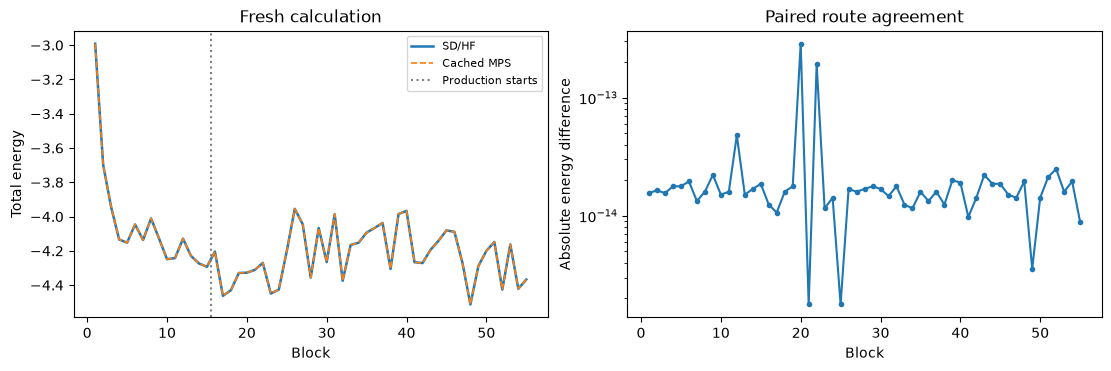

SD: -4.229002843496098; MPS: -4.229002843496110
Mean difference: 1.155e-14; maximum block difference: 2.860e-13
Worst errors: {'walkers': 0.0, 'weights': 3.8232306209806666e-11, 'overlaps': 1.2953860206721401e-11, 'shift': 1.021271955892189e-11, 'energy': 1.687538997430238e-14, 'nodes': 0.0, 'proposals': 1.1652900866465643e-11, 'probabilities': 3.0705993303570267e-12, 'raw_energy': 1.007194327939942e-11}


In [18]:
import matplotlib.pyplot as plt
view = portable_result if 'portable_result' in globals() else RECORDED['full']['result']
label = 'Fresh calculation' if 'portable_result' in globals() else 'Recorded NumPy calculation'
ea, eb = np.asarray(view['sd_energies']), np.asarray(view['mps_energies'])
blocks = np.arange(1, len(ea)+1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].plot(blocks, ea, label='SD/HF', lw=1.8)
axes[0].plot(blocks, eb, '--', label='Cached MPS', lw=1.2)
axes[0].axvline(view['nequil']+0.5, color='0.5', ls=':', label='Production starts')
axes[0].set(xlabel='Block', ylabel='Total energy', title=label)
axes[0].legend(fontsize=8)
axes[1].semilogy(blocks, np.maximum(abs(ea-eb), np.finfo(float).eps), '.-')
axes[1].set(xlabel='Block', ylabel='Absolute energy difference', title='Paired route agreement')
plt.show()
print(f"SD: {view['sd_mean']:.15f}; MPS: {view['mps_mean']:.15f}")
print(f"Mean difference: {view['mean_error']:.3e}; maximum block difference: {view['max_block_error']:.3e}")
print('Worst errors:', view['worst'])


## 12. What to extend next

1. **DMRG trial:** replace `model.trial` and construct the matching `model.htrial` in the same local basis/site ordering and particle sector. The HS cache is unchanged. Keep the Slater conversion plans tied to the walker spin populations; they do not come from DMRG site densities. Verify overlaps and local energies independently on a small model first. The native helper currently builds an HF trial container and would need a suitable initializer/callback wrapper for a DMRG production trial.
2. **Finite-$B$ / finite-bond approximation:** introduce it explicitly, report conversion error and discarded weights, then compare raw overlap ratios as well as energies against this exact endpoint. The single-projector replay is valid here because the full remaining block is a projector; it cannot simply replace the original filter in a truncated subblock.
3. **Larger-system performance:** profile conversion versus contractions first. Caching removes $2L$ reconstructions per step, but exact bonds are still large. Padded/bucketed bond shapes could enable a compiled site scan; this implementation uses a static Python site loop because the exact bond shapes differ by site. JAX batches walkers with `vmap` and compiles whole steps/blocks. Measure compilation separately from steady state.
4. **Longer or harder runs:** monitor overlap conditioning, conversion leakage, constraint events and decision margins. Add scale/log-overlap bookkeeping if the existing scalar range becomes insufficient. A longer statistical convergence study, time-step extrapolation, doped systems, complex/phaseless propagation and general geometry are outside this real open-chain verification.

The acceptance criterion here is representation equivalence at maximal $B$, with full AFQMC mechanics. It is not an assertion that finite-$B$ walkers, a different trial, or a different constraint policy produce the same trajectory.
